In [ ]:

from google.colab import files
files.upload()


Saving leaf_image2.png to leaf_image2.png


{'leaf_image2.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01\x96\x00\x00\x00\xff\x08\x06\x00\x00\x00\xd2t\xf0\xb0\x00\x00\x00\x01sRGB\x00\xae\xce\x1c\xe9\x00\x00\x00\x04gAMA\x00\x00\xb1\x8f\x0b\xfca\x05\x00\x00\x00\tpHYs\x00\x00\x0e\xc3\x00\x00\x0e\xc3\x01\xc7o\xa8d\x00\x00\xff\xa5IDATx^\xec\xfdY\x93$9\x92&\x08~\x00DT\xd5\x0e?\xe2>\xf2\xa8\xac\xcc\xca:\xb3\xa6{\xaa\xbbi\xab\x89\x86\xba\xb7\x9ewi\x1f\x9a\xfa\x07\xe5\x8f\x9a\xa6\x9d\x87\x99%\xaa\xea\xde\xe9\xd9\xbe\xaa\xb2*\xe3\xbeo\x0f\xbf\x0f;TE\x04\xc0>0\x7f",0Q35s\xb7\x08\xf3\x08e\x0f\x84\x89\x8a\xe0`0\x00f\x80\xc1`\xb8\x9cs\xfeO\xff\xed\xefq\x99\xe0\x9c+_MB\xce\x19\xd0\xf86\xf0\x9b\r\xce9x\xefO\xa4\xb5\xb0i\xb9Sp\xde\xa4eY\xf6\xb7}.\xf1\xb4\xbf\xcbo0\xb4\xb8\x08<\xcb\xbcS:\x99\xfe\xaa\xc3T\x9d\x9f5lH\xbe\xef\x04\x97\xf3\x80\x1dW\x84u8n\xdaG\xd6$_;\x16RJ\xfd\xf3\xd9\xb0&\xf3g\x00\xeb\xea}Y\xb0\x8e\x1e\x17\x81\xa7M\xbf\x0e\xce\xd76\'a\xe0\xccW\x14(H\x9egx\xde\xf1\xff\xb1\x00\xfb\xda\xa6\xe12\x99\xdd\x16\xb6\xf0<\xc3\x95\x12,\

In [ ]:
pip install opencv-python matplotlib torch torchvision

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git



  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-7gp7zbhp
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-7gp7zbhp
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=80002c2079e16fa589f6c33bada38675121a3bcc0104a4258a9766ae3ec2ed20
  Stored in directory: /tmp/pip-ephem-wheel-cache-68k8ty0x/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth


--2026-01-13 12:50:48--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.155.173.116, 18.155.173.79, 18.155.173.40, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.155.173.116|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G  88.8MB/s    in 18s     

2026-01-13 12:51:06 (133 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



✅ Found and loading: leaf_image2.png


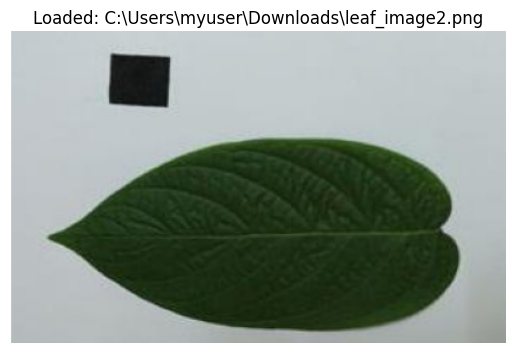

In [ ]:
import cv2
import glob
import os
from matplotlib import pyplot as plt

# This looks for ANY file ending in .png or .PNG
png_files = glob.glob("*.png") + glob.glob("*.PNG")

if len(png_files) == 0:
    print("❌ No PNG files found! Did you upload it?")
    print("Current files in folder:", os.listdir())
else:
    # Pick the first PNG found
    image_path = png_files[0]
    print(f"✅ Found and loading: {image_path}")

    image_bgr = cv2.imread(image_path)
    image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    plt.imshow(image)
    plt.title(f"Loaded: {r"C:\Users\myuser\Downloads\leaf_image2.png"}")
    plt.axis('off')
    plt.show()

✅ Image loaded successfully


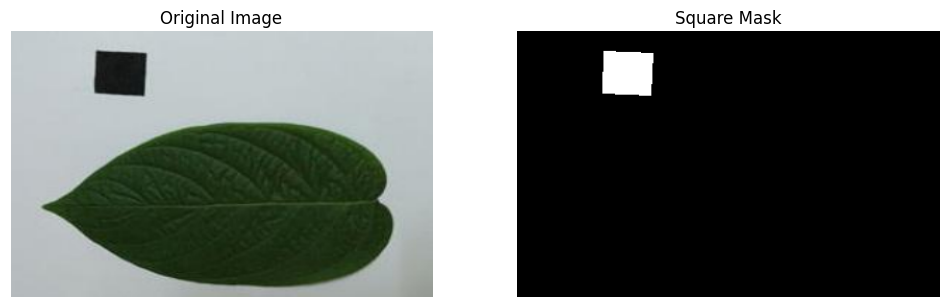

✅ square_mask.png saved
Square pixel count: 1950


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# LOAD IMAGE
# ----------------------------
image_path = "leaf_image2.png"  # uploaded to Colab working directory

image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise FileNotFoundError("❌ Image not found. Check filename.")

image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
print("✅ Image loaded successfully")

# ============================================================
# SQUARE DETECTION (OpenCV ONLY)
# ============================================================

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Otsu thresholding (robust to lighting)
_, thresh = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Remove noise
kernel = np.ones((5, 5), np.uint8)
thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Find contours
contours, _ = cv2.findContours(
    thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

square_contour = None
max_area = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 300:   # ignore small noise
        continue

    # Polygon approximation
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)

    if len(approx) == 4:  # rectangle/square
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / float(h)

        # Square check
        if 0.85 < aspect_ratio < 1.15:
            if area > max_area:
                max_area = area
                square_contour = approx

if square_contour is None:
    raise RuntimeError("❌ Square not detected. Improve contrast or lighting.")

# Create square mask
square_mask = np.zeros(gray.shape, dtype=np.uint8)
cv2.drawContours(square_mask, [square_contour], -1, 255, -1)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Square Mask")
plt.imshow(square_mask, cmap="gray")
plt.axis("off")

plt.show()

# ============================================================
# SAVE OUTPUT
# ============================================================

cv2.imwrite("square_mask.png", square_mask)
print("✅ square_mask.png saved")

# ============================================================
# PIXEL COUNT
# ============================================================

square_pixels = np.sum(square_mask > 0)
print("Square pixel count:", square_pixels)


Total masks generated: 75


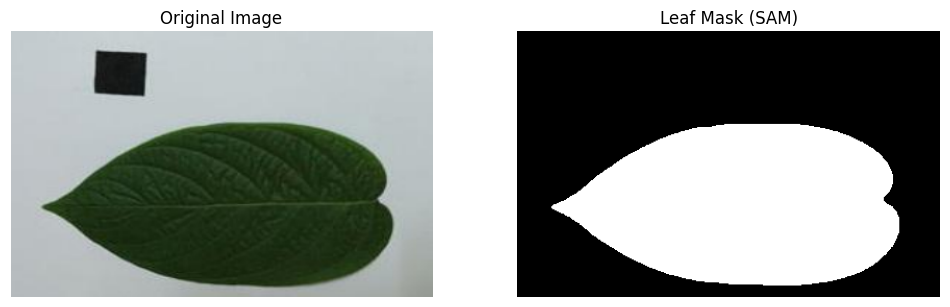

Leaf mask saved as leaf_mask.png


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# --------------------------------------------------
# DEVICE
# --------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# LOAD IMAGE
# --------------------------------------------------
image_path = "leaf_image2.png"   # your leaf image
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    raise FileNotFoundError("Image not found")

image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# --------------------------------------------------
# LOAD SAM MODEL (OFFICIAL WAY)
# --------------------------------------------------
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device)

# --------------------------------------------------
# AUTOMATIC MASK GENERATION
# --------------------------------------------------
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    crop_n_layers=1,
    min_mask_region_area=1000
)

masks = mask_generator.generate(image)
print("Total masks generated:", len(masks))

# --------------------------------------------------
# SELECT LEAF MASK
# --------------------------------------------------
from segment_anything import SamPredictor

predictor = SamPredictor(sam)
predictor.set_image(image)

# click a point inside the leaf
point_coords = np.array([[image.shape[1]//2, image.shape[0]//2]])
point_labels = np.array([1])

masks, scores, _ = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True
)

leaf_mask = masks[np.argmax(scores)].astype(np.uint8) * 255



# --------------------------------------------------
# VISUALIZATION
# --------------------------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Leaf Mask (SAM)")
plt.imshow(leaf_mask, cmap="gray")
plt.axis("off")

plt.show()

# --------------------------------------------------
# SAVE MASK
# --------------------------------------------------
cv2.imwrite("leaf_mask.png", leaf_mask)
print("Leaf mask saved as leaf_mask.png")


In [ ]:
import numpy as np

# leaf_mask obtained from SAM (Option 2)
# shape: (H, W), values: 0 or 255

leaf_pixels = np.sum(leaf_mask > 0)

print(f"Leaf pixel count: {leaf_pixels}")


Leaf pixel count: 38676


In [ ]:
# STANDALONE LEAF AREA CALCULATION
# ============================================================

# 1. Input the values from your previous output
leaf_pixels = 38676
square_pixels = 1950

# 2. Define your constant
SQUARE_AREA_CM2 = 4.0  # 4 cm^2 reference

# 3. Apply your formula
# leaf_area_cm2 = (leaf_pixels / square_pixels) * SQUARE_AREA_CM2
leaf_area_cm2 = (leaf_pixels / square_pixels) * SQUARE_AREA_CM2

# 4. Print results
print("="*40)
print(f"🍃 LEAF AREA CALCULATION")
print("="*40)
print(f"Formula: ({leaf_pixels} / {square_pixels}) * {SQUARE_AREA_CM2}")
print("-" * 40)
print(f"TOTAL LEAF AREA: {leaf_area_cm2:.4f} cm²")
print("="*40)

🍃 LEAF AREA CALCULATION
Formula: (38676 / 1950) * 4.0
----------------------------------------
TOTAL LEAF AREA: 79.3354 cm²


In [ ]:
# code for self generated image
from google.colab import files
files.upload()

Saving leaf_image3.2.jpeg to leaf_image3.2.jpeg


{'leaf_image3.2.jpeg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\x06\x06\x06\x06\x07\x06\x07\x08\x08\x07\n\x0b\n\x0b\n\x0f\x0e\x0c\x0c\x0e\x0f\x16\x10\x11\x10\x11\x10\x16"\x15\x19\x15\x15\x19\x15"\x1e$\x1e\x1c\x1e$\x1e6*&&*6>424>LDDL_Z_||\xa7\x01\x06\x06\x06\x06\x07\x06\x07\x08\x08\x07\n\x0b\n\x0b\n\x0f\x0e\x0c\x0c\x0e\x0f\x16\x10\x11\x10\x11\x10\x16"\x15\x19\x15\x15\x19\x15"\x1e$\x1e\x1c\x1e$\x1e6*&&*6>424>LDDL_Z_||\xa7\xff\xc2\x00\x11\x08\x04\xb0\x06@\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x000\x00\x01\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\xff\xda\x00\x0c\x03\x01\x00\x02\x10\x03\x10\x00\x00\x02\xfa\xe3 "\x89e\x08\x05%\x04\xa0\t@P\x00\x00\x00\x01IA(\x94\x00\x00\x00\x00YT\x04\xa2P\x08\x00\x00\x00\x00\x05\x96\xa0@\x00\x00\x05\x00\x00\x00\x05\x94\x00\x00\x00\x00R\x00\x00*P\x00\x00\x00PB\x80\x00\x00

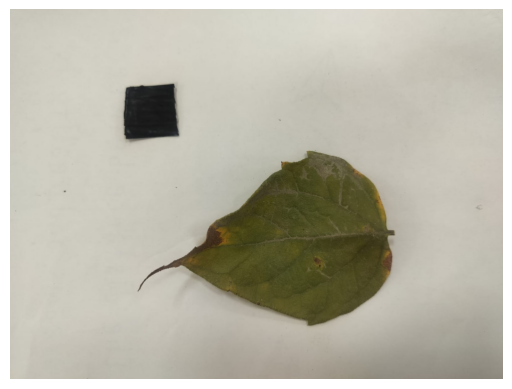

In [ ]:
import cv2
from matplotlib import pyplot as plt

image_path = 'leaf_image3.2.jpeg'

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("❌ Image not found. Check filename and upload.")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')
plt.show()


Total masks generated: 19


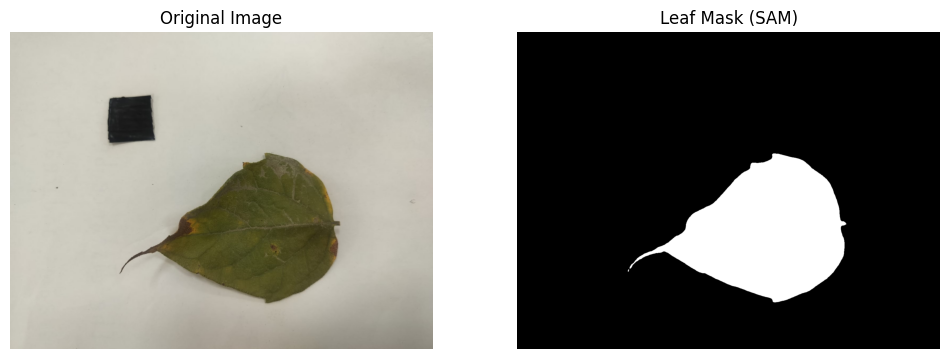

Leaf mask saved as leaf_mask.png


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# --------------------------------------------------
# DEVICE
# --------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# LOAD IMAGE
# --------------------------------------------------
image_path = "leaf_image3.2.jpeg"   # your leaf image
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    raise FileNotFoundError("Image not found")

image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# --------------------------------------------------
# LOAD SAM MODEL (OFFICIAL WAY)
# --------------------------------------------------
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device)

# --------------------------------------------------
# AUTOMATIC MASK GENERATION
# --------------------------------------------------
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    crop_n_layers=1,
    min_mask_region_area=1000
)

masks = mask_generator.generate(image)
print("Total masks generated:", len(masks))

# --------------------------------------------------
# SELECT LEAF MASK
# --------------------------------------------------
from segment_anything import SamPredictor
import numpy as np

predictor = SamPredictor(sam)
predictor.set_image(image)

# Positive point inside leaf
# Negative point inside square
point_coords = np.array([
    [image.shape[1] // 2, image.shape[0] // 2],  # leaf
    [50, 50]                                     # square (adjust if needed)
])

point_labels = np.array([1, 0])  # 1 = include, 0 = exclude

masks, scores, _ = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True
)

leaf_mask = masks[np.argmax(scores)].astype(np.uint8) * 255


# --------------------------------------------------
# VISUALIZATION
# --------------------------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Leaf Mask (SAM)")
plt.imshow(leaf_mask, cmap="gray")
plt.axis("off")

plt.show()

# --------------------------------------------------
# SAVE MASK
# --------------------------------------------------
cv2.imwrite("leaf_mask.png", leaf_mask)
print("Leaf mask saved as leaf_mask.png")


In [ ]:
import matplotlib.pyplot as plt

def show_mask(mask, title="Mask"):
    plt.figure(figsize=(5,5))
    plt.imshow(mask, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


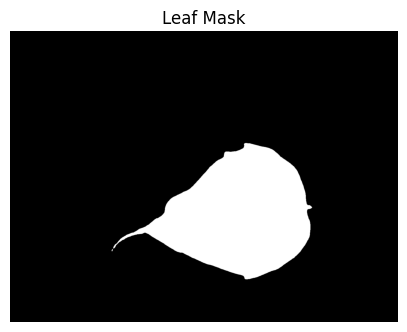

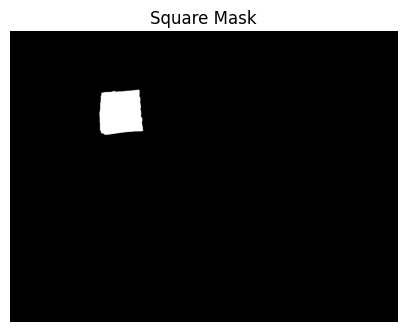

In [ ]:
show_mask(leaf_mask, "Leaf Mask")
show_mask(square_mask, "Square Mask")


In [ ]:
leaf_pixels = np.sum(leaf_mask > 0)
print("Leaf pixel count:", leaf_pixels)
square_pixels = np.sum(square_mask > 0)
print("Square pixel count:", square_pixels)


Leaf pixel count: 246183
Square pixel count: 28993


In [ ]:
 SQUARE_AREA_CM2 = 4.0

if square_pixels == 0:
    raise ValueError("Square pixel count is zero — cannot compute area")

leaf_area_cm2 = (leaf_pixels / square_pixels) * SQUARE_AREA_CM2

print(f"Leaf Area: {leaf_area_cm2:.2f} cm²")


Leaf Area: 33.96 cm²


In [ ]:
from google.colab import files
files.upload()

Saving leaf_image5.1.jpeg to leaf_image5.1.jpeg


{'leaf_image5.1.jpeg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\x06\x06\x06\x06\x07\x06\x07\x08\x08\x07\n\x0b\n\x0b\n\x0f\x0e\x0c\x0c\x0e\x0f\x16\x10\x11\x10\x11\x10\x16"\x15\x19\x15\x15\x19\x15"\x1e$\x1e\x1c\x1e$\x1e6*&&*6>424>LDDL_Z_||\xa7\x01\x06\x06\x06\x06\x07\x06\x07\x08\x08\x07\n\x0b\n\x0b\n\x0f\x0e\x0c\x0c\x0e\x0f\x16\x10\x11\x10\x11\x10\x16"\x15\x19\x15\x15\x19\x15"\x1e$\x1e\x1c\x1e$\x1e6*&&*6>424>LDDL_Z_||\xa7\xff\xc2\x00\x11\x08\x03\xc0\x05\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00.\x00\x01\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\xff\xda\x00\x0c\x03\x01\x00\x02\x10\x03\x10\x00\x00\x02\xfae\xca(\x94\x16P\x05\x01IA(\x85%\x02\x80\x05"\x89@\x00\x05 \x05 \x00\xb0\x00(\x01,\x0b\x00\x12\xc1`\xa0\x02\x00\x00\x01\x00\x00\x02P\x05\x94\x8a%B\x80\tB)b\x88\x00\n\x12\x88\xa0\x08\xa2\x02\x00\x04\xa36\xc0

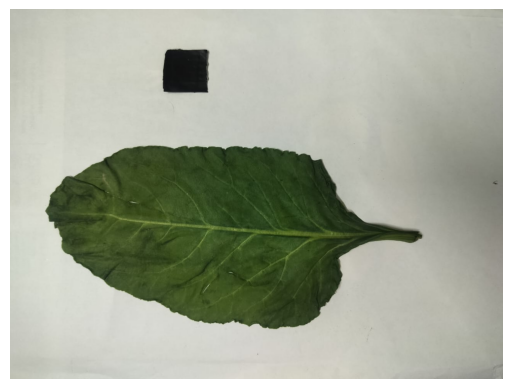

In [ ]:
import cv2
from matplotlib import pyplot as plt

image_path = 'leaf_image5.1.jpeg'

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("❌ Image not found. Check filename and upload.")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')
plt.show()

Total masks generated: 16


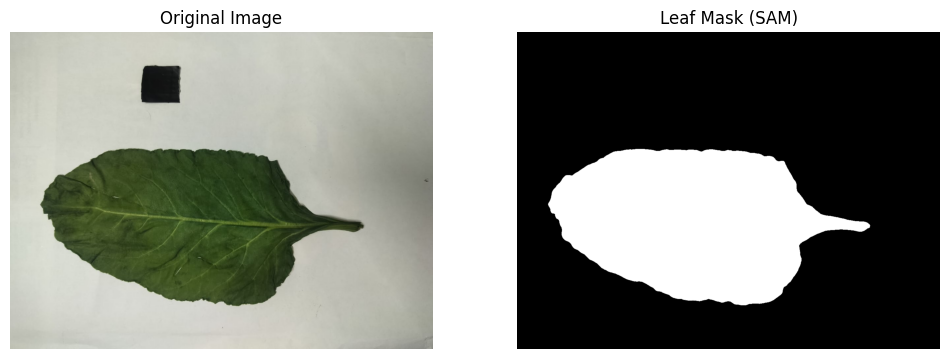

Leaf mask saved as leaf_mask.png


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# --------------------------------------------------
# DEVICE
# --------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# LOAD IMAGE
# --------------------------------------------------
image_path = "leaf_image5.1.jpeg"   # your leaf image
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    raise FileNotFoundError("Image not found")

image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# --------------------------------------------------
# LOAD SAM MODEL (OFFICIAL WAY)
# --------------------------------------------------
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device)

# --------------------------------------------------
# AUTOMATIC MASK GENERATION
# --------------------------------------------------
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.95,
    crop_n_layers=1,
    min_mask_region_area=1000
)

masks = mask_generator.generate(image)
print("Total masks generated:", len(masks))

# --------------------------------------------------
# SELECT LEAF MASK
# --------------------------------------------------
from segment_anything import SamPredictor
import numpy as np

predictor = SamPredictor(sam)
predictor.set_image(image)

# Positive point inside leaf
# Negative point inside square
point_coords = np.array([
    [image.shape[1] // 2, image.shape[0] // 2],  # leaf
    [50, 50]                                     # square (adjust if needed)
])

point_labels = np.array([1, 0])  # 1 = include, 0 = exclude

masks, scores, _ = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True
)

leaf_mask = masks[np.argmax(scores)].astype(np.uint8) * 255


# --------------------------------------------------
# VISUALIZATION
# --------------------------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Leaf Mask (SAM)")
plt.imshow(leaf_mask, cmap="gray")
plt.axis("off")

plt.show()

# --------------------------------------------------
# SAVE MASK
# --------------------------------------------------
cv2.imwrite("leaf_mask.png", leaf_mask)
print("Leaf mask saved as leaf_mask.png")


✅ Image loaded successfully


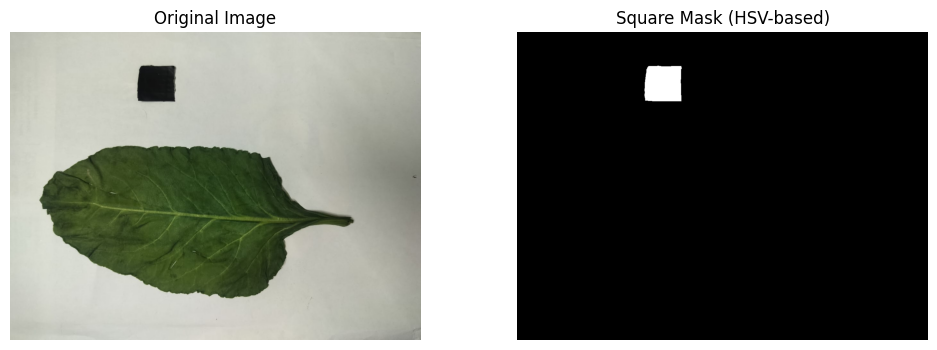

Square pixel count: 12197
✅ square_mask_hsv.png saved


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# LOAD IMAGE
# ----------------------------
image_path = "leaf_image5.1.jpeg"

image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise FileNotFoundError("❌ Image not found")

image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
print("✅ Image loaded successfully")

# ============================================================
# SQUARE DETECTION (HSV + CONNECTED COMPONENTS)
# ============================================================

# Convert to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# Black color range (tuned for matte black paper)
lower_black = np.array([0, 0, 0])
upper_black = np.array([180, 255, 60])

black_mask = cv2.inRange(hsv, lower_black, upper_black)

# Clean noise
kernel = np.ones((5,5), np.uint8)
black_mask = cv2.morphologyEx(black_mask, cv2.MORPH_OPEN, kernel)
black_mask = cv2.morphologyEx(black_mask, cv2.MORPH_CLOSE, kernel)

# Connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
    black_mask, connectivity=8
)

square_mask = np.zeros_like(black_mask)

for i in range(1, num_labels):  # skip background
    area = stats[i, cv2.CC_STAT_AREA]
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]

    # Filter by size
    if area < 300:
        continue

    aspect_ratio = w / float(h)

    # Square-like shape
    if 0.85 < aspect_ratio < 1.15:
        square_mask[labels == i] = 255
        break

if np.sum(square_mask) == 0:
    raise RuntimeError("❌ Square not detected")

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Square Mask (HSV-based)")
plt.imshow(square_mask, cmap="gray")
plt.axis("off")

plt.show()

# ============================================================
# SAVE + PIXEL COUNT
# ============================================================

cv2.imwrite("square_mask_hsv.png", square_mask)

square_pixels = cv2.countNonZero(square_mask)
print("Square pixel count:", square_pixels)
print("✅ square_mask_hsv.png saved")


In [ ]:
import matplotlib.pyplot as plt

def show_mask(mask, title="Mask"):
    plt.figure(figsize=(5,5))
    plt.imshow(mask, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


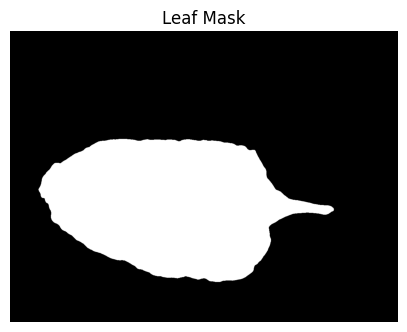

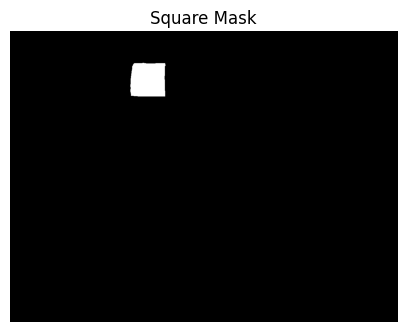

In [ ]:
show_mask(leaf_mask, "Leaf Mask")
show_mask(square_mask, "Square Mask")


In [ ]:
leaf_pixels = np.sum(leaf_mask > 0)
print("Leaf pixel count:", leaf_pixels)
square_pixels = np.sum(square_mask > 0)
print("Square pixel count:", square_pixels)


Leaf pixel count: 297003
Square pixel count: 12197


In [ ]:
# STANDALONE LEAF AREA CALCULATION
# ============================================================

# 1. Input the values from your previous output
leaf_pixels = 297003
square_pixels = 12197

# 2. Define your constant
SQUARE_AREA_CM2 = 4.0  # 4 cm^2 reference

# 3. Apply your formula
# leaf_area_cm2 = (leaf_pixels / square_pixels) * SQUARE_AREA_CM2
leaf_area_cm2 = (leaf_pixels / square_pixels) * SQUARE_AREA_CM2

# 4. Print results
print("="*40)
print(f"🍃 LEAF AREA CALCULATION")
print("="*40)
print(f"Formula: ({leaf_pixels} / {square_pixels}) * {SQUARE_AREA_CM2}")
print("-" * 40)
print(f"TOTAL LEAF AREA: {leaf_area_cm2:.4f} cm²")
print("="*40)


🍃 LEAF AREA CALCULATION
Formula: (297003 / 12197) * 4.0
----------------------------------------
TOTAL LEAF AREA: 97.4020 cm²
